# Task 1: Predicting House Prices with Linear Regression

## Project Objective

The objective of this project is to build a Linear Regression model to predict house prices based on different housing features. The project includes data preprocessing, exploratory data analysis, feature engineering, model training, evaluation, and interpretation of results.

## 1. Import Libraries

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge

from sklearn.metrics import mean_squared_error, r2_score

## 2. Load Dataset

The housing dataset is loaded into a pandas DataFrame for analysis.

In [33]:
df = pd.read_csv("Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 3. Initial Data Inspection

This section examines the structure, data types, missing values, and descriptive statistics of the dataset before preprocessing.

In [34]:
df.shape

(545, 13)

In [35]:
df.shape

(545, 13)

In [36]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [37]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## 4. Distribution of House Prices

The distribution of the target variable (price) is visualized to understand its spread.

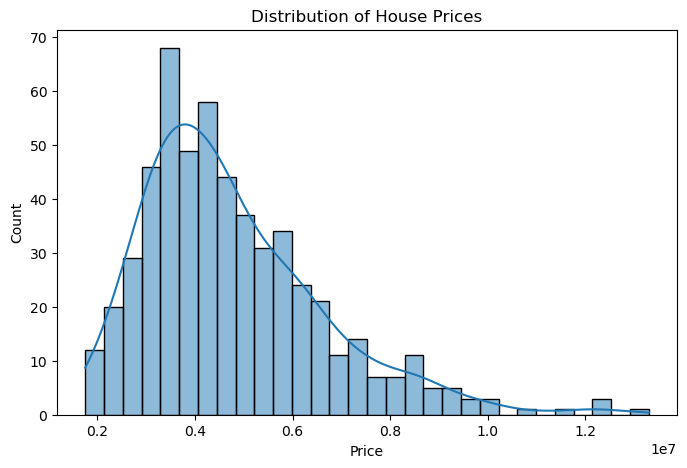

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

### **Observation**

### The histogram shows the distribution of house prices in the dataset. This helps identify whether the target variable is normally distributed or skewed.

## 5. Feature Selection

The target variable in this project is `price`.

The features likely to influence house prices include:

- `area`: Larger houses generally have higher prices.
- `bedrooms`: The number of bedrooms can affect the value of a property.
- `bathrooms`: More bathrooms may increase the house price.
- `stories`: The number of floors can influence property value.
- `parking`: Houses with more parking spaces may have higher prices.
- `mainroad`: Access to a main road can influence property value.
- `guestroom`: Availability of a guest room may affect the price.
- `basement`: A basement can add value to a property.
- `hotwaterheating`: Additional facilities may increase property value.
- `airconditioning`: Air conditioning can contribute to a higher house price.
- `prefarea`: Properties in preferred areas may have higher prices.
- `furnishingstatus`: Furnishing condition can significantly affect price.

These features are selected because they represent physical characteristics, facilities, location-related factors, and amenities that can influence the market value of a house.

## 6. Correlation Analysis

Correlation analysis is used to understand the relationship between numerical variables and house price. A positive correlation indicates that two variables tend to increase together, while a negative correlation indicates an inverse relationship.

In [39]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation["price"].sort_values(ascending=False)

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

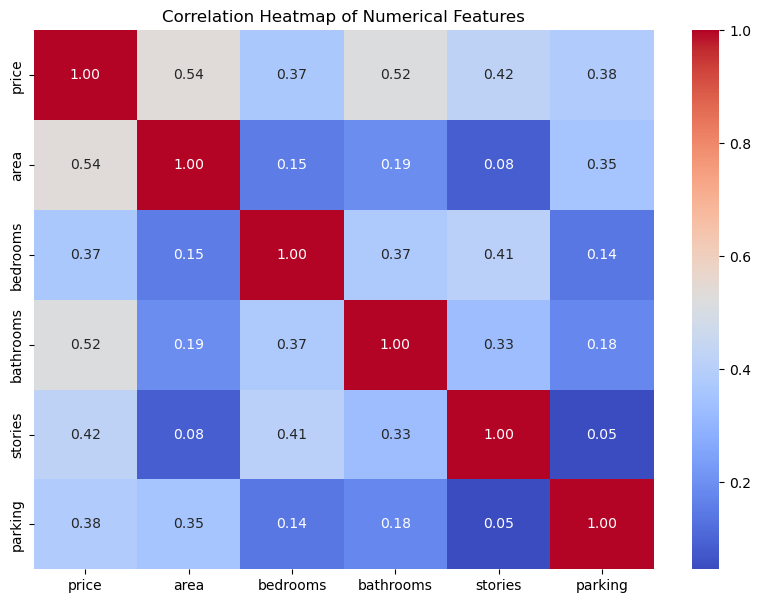

In [40]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### **Observation**

### The correlation analysis shows how strongly the numerical features are associated with house price. The heatmap helps identify the features that have relatively stronger positive or negative relationships with the target variable `price`.

In [41]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

## 7. Data Preprocessing

The dataset contains both numerical and categorical features. Numerical features can be used directly by the regression model, while categorical features need to be converted into numerical form.

One-Hot Encoding is used to transform categorical variables into binary columns so that they can be processed by the Linear Regression model.

In [42]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

### Observation

The dataset contains no missing values, so no imputation is required before model training.

## 8. Encoding Categorical Features

The categorical features are converted into numerical features using One-Hot Encoding. This creates separate binary columns for each category while allowing the machine learning model to use the information contained in categorical variables.

In [43]:
X = df.drop("price", axis=1)
y = df["price"]

categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

### Observation

The target variable `price` was separated from the predictor variables. Numerical features were retained as they are, while categorical features were prepared for One-Hot Encoding. The `drop="first"` option avoids redundant dummy variables.

## 9. Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio. The training data is used to build the model, while the testing data is used to evaluate its performance on unseen data.

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 436
Testing samples: 109


## 10. Linear Regression Model

Linear Regression is used to predict house prices based on the selected numerical and categorical features. The preprocessing pipeline first applies One-Hot Encoding to categorical variables and then trains the Linear Regression model.

In [45]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

print("Model training completed successfully.")

Model training completed successfully.


### **Observation**

### The dataset was successfully divided into training and testing sets using an 80:20 ratio. A Linear Regression model was then trained using the preprocessing pipeline, which automatically handles the categorical feature encoding before prediction.

## 11. Model Evaluation

The Linear Regression model is evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

MSE measures the average squared difference between actual and predicted prices. RMSE is the square root of MSE and represents prediction error in the same unit as the target variable. R² indicates how much variation in house prices is explained by the model.

In [46]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 1754318687330.684
Root Mean Squared Error (RMSE): 1324506.9600914463
R² Score: 0.6529242642153144


### **Observation**

### The Linear Regression model was evaluated using MSE, RMSE, and R² score. A lower MSE and RMSE indicate smaller prediction errors, while a higher R² score indicates that the model explains a larger proportion of the variation in house prices.

## 12. Actual vs Predicted House Prices

This scatter plot compares the actual house prices with the prices predicted by the Linear Regression model. Points closer to the diagonal reference line indicate more accurate predictions.

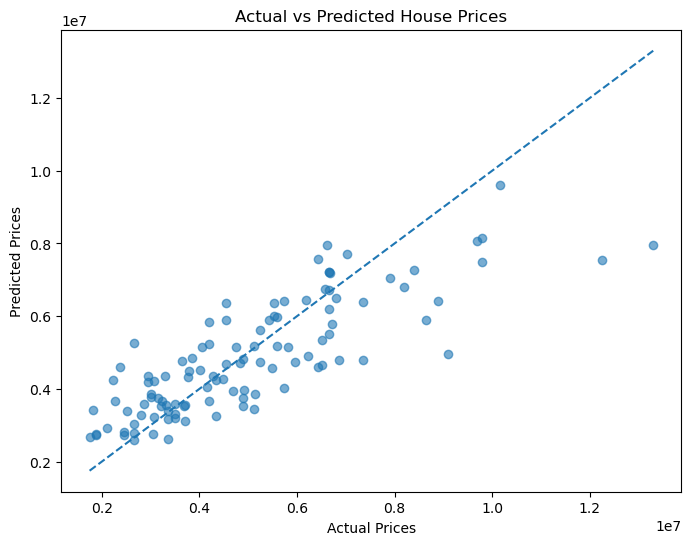

In [47]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

### **Observation**

### The scatter plot compares actual and predicted house prices. Predictions closer to the diagonal reference line indicate better model performance, while points farther from the line represent larger prediction errors.

## 13. Residual Analysis

Residuals are the differences between the actual and predicted house prices. A residual plot is used to check whether the errors are randomly distributed around zero. A random pattern without a clear systematic trend generally indicates that the model is capturing the relationship between the features and the target reasonably well.

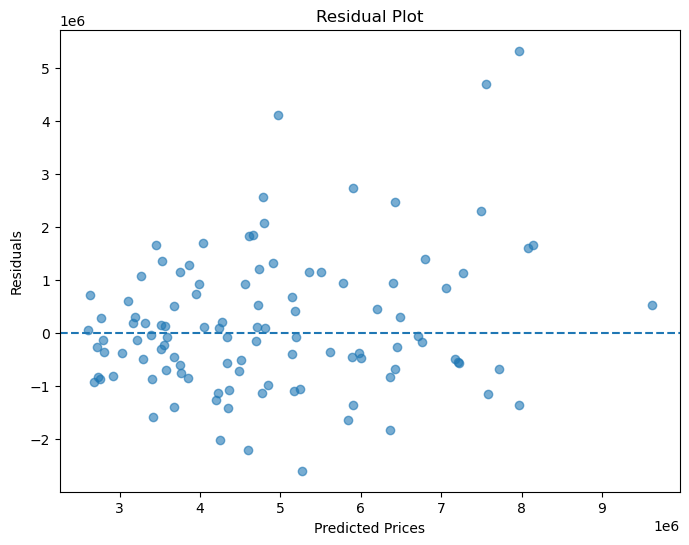

In [48]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

### **Observation**

### The residual plot shows the prediction errors against the predicted house prices. The distribution of residuals can be examined for systematic patterns. A more random distribution around zero indicates that there is no strong systematic pattern in the model errors.

## 14. Coefficient Analysis

The coefficients of the Linear Regression model indicate the direction and relative impact of the input features on predicted house prices. Positive coefficients indicate a positive relationship with the predicted price, while negative coefficients indicate a negative relationship, keeping other features constant.

In [49]:
feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()

coefficients = linear_model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coef_df.head(10)

,Feature,Coefficient,Absolute_Coefficient
10,num__bathrooms,1.094445e+06,1.094445e+06
4,cat__airconditioning_yes,7.914267e+05,7.914267e+05
3,cat__hotwaterheating_yes,6.846499e+05,6.846499e+05
5,cat__prefarea_yes,6.298906e+05,6.298906e+05
7,cat__furnishingstatus_unfurnished,-4.136451e+05,4.136451e+05
11,num__stories,4.074766e+05,4.074766e+05
2,cat__basement_yes,3.902512e+05,3.902512e+05
0,cat__mainroad_yes,3.679199e+05,3.679199e+05
1,cat__guestroom_yes,2.316100e+05,2.316100e+05
12,num__parking,2.248419e+05,2.248419e+05


### Observation

The coefficient analysis identifies the features with the strongest positive and negative effects on predicted house prices. Positive coefficients indicate features associated with higher predicted prices, while negative coefficients indicate features associated with lower predicted prices, assuming other variables remain constant.

## 15. Bonus: Ridge Regression

Ridge Regression is a regularized version of Linear Regression. It applies an L2 penalty to the model coefficients, which can help reduce overfitting and improve model stability when features are correlated.

In [50]:
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=1.0))
    ]
)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge MSE:", ridge_mse)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R² Score:", ridge_r2)

Ridge MSE: 1756474279575.2847
Ridge RMSE: 1325320.4441097574
Ridge R² Score: 0.652497800215501


In [51]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "RMSE": [rmse, ridge_rmse],
    "R2 Score": [r2, ridge_r2]
})

comparison

,Model,MSE,RMSE,R2 Score
0,Linear Regression,1.754319e+12,1.324507e+06,0.652924
1,Ridge Regression,1.756474e+12,1.325320e+06,0.652498


### Observation

Linear Regression and Ridge Regression were compared using MSE, RMSE, and R² score. The model with the lower RMSE and higher R² score provides better predictive performance on the test dataset.

## 16. Conclusion

A Linear Regression model was developed to predict house prices using numerical and categorical housing features. The dataset was explored, checked for missing values, and categorical variables were converted using One-Hot Encoding.

The correlation analysis showed that area, bathrooms, stories, parking, and bedrooms had positive relationships with house prices. Coefficient analysis further identified the features with the strongest influence on the model's predictions.

The Linear Regression model achieved an R² score of approximately 0.653 on the test dataset, explaining around 65.3% of the variation in house prices.

A Ridge Regression model was also tested as a regularized alternative. Linear Regression performed slightly better than Ridge Regression based on the test RMSE and R² score.

### Business Insights and Recommendations

1. **Focus on property size and facilities:** Area and the number of bathrooms showed strong relationships with house prices. Developers and sellers should consider these factors when pricing properties.

2. **Invest in valuable amenities:** Features such as air conditioning, hot water heating, and preferred-area location showed positive model coefficients and may contribute to higher property values.

3. **Use data-driven pricing:** Real-estate businesses can use regression models as a supporting tool for estimating property prices and identifying important pricing factors.

Overall, the project demonstrates an end-to-end machine learning workflow from exploratory data analysis and preprocessing to model training, evaluation, interpretation, and comparison with a regularized model.